# 净电荷和电子能量的小规模输运扫描

## tl;dr
用同一组束流参数比较正负净电荷及两档电子能量；正式大规模扫描使用命令行断点续跑。

## Context & Methods

此 notebook 每组只发射 300 个电子，展示运行路径与输出格式。正式结果需要增加 `n_simulated`、做独立随机种子复算并检查统计误差。

In [1]:
# 所有 Notebook 都从项目根目录读取配置和写入 results/。
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
# 不要求先 pip install；优先直接导入当前工作树中的源码。
sys.path.insert(0, str(ROOT / 'src'))
import droplet_shadow
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'figure.figsize': (7, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

In [2]:
# 六点小扫描只展示参数如何替换和结果如何保存，不足以做灵敏度结论。
from droplet_shadow import load_config, simulate
base = load_config(ROOT / 'examples/baseline-geant4.yaml').with_updates(run={'n_simulated': 300, 'exposure_electrons': 300})
results = {}
for energy in [1, 3]:
    for q in [-1e7, 0, 1e7]:
        cfg = base.with_updates(source={'energy_mev': energy}, charge={'q_e': q})
        results[(energy, q)] = simulate(cfg, ROOT / f'results/notebook_scan_E{energy}_Q{q:+.0f}')
print('Completed', len(results), 'Geant4 cases')

Completed 6 Geant4 cases


## Results

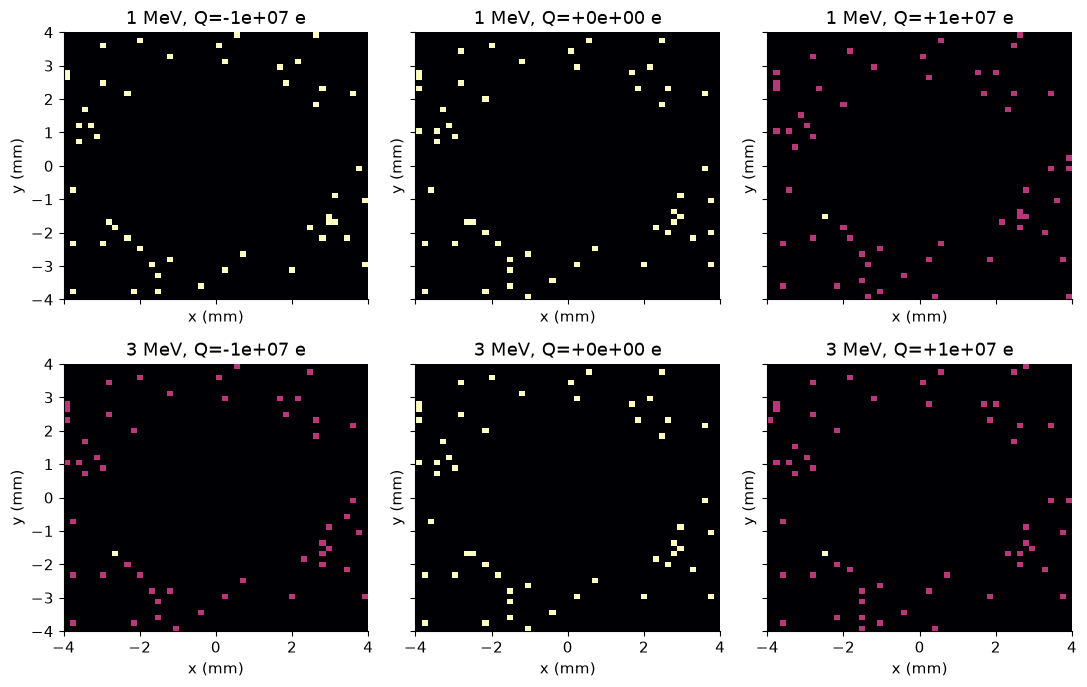

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(11, 7), sharex=True, sharey=True)
for (energy, q), ax in zip(results, axes.flat):
    hits = results[(energy, q)].hits
    ax.hist2d(hits['x_m']*1e3, hits['y_m']*1e3, bins=50, range=[[-4,4],[-4,4]], cmap='magma')
    ax.set(title=f'{energy} MeV, Q={q:+.0e} e', xlabel='x (mm)', ylabel='y (mm)')
fig.tight_layout(); plt.show()

## Takeaways

比较相同能量、几何和探测器条件下的图像。低计数示例只说明计算链路可以运行；不能根据这六幅稀疏图像宣布检出限。